# Тест 5 — каты, убирающие ложные срабатывания, и чего они стоят

## Вопрос

Практический: **какие каты убирают ложноположительную выборку атмосферных
мюонов, что при этом происходит с экспериментальными событиями, и насколько
падает эффективность на нейтрино.**

## Что кат учится различать

Оба класса — **одни и те же атмосферные мюоны** из одного генератора: те, кому
классификатор поставил скор выше 0.5 (все атмосферные мюоны фон, поэтому любое
их принятие ошибочно), против тех, кого он уверенно отверг со скором ниже 0.01.
Различает эти выборки только обманчивость, значит дискриминатор между ними
выучивает именно её.

Учить кат отличать ложные срабатывания от нейтрино было бы бессмысленно: это
ровно то, что уже делает классификатор.

**Экспериментальные данные и нейтрино в конструировании не участвуют.** Правила
подгоняются только на симуляции; экспериментальная выборка входит в одну
функцию — оценивающую. Поэтому их выживаемость есть предсказание, а не цель.

**Балансировка подвыборкой, а не весами**, в пяти непересекающихся повторах.
**Низкоскоровый контроль в обеих выборках** — иначе «кат убрал обманчивые мюоны»
неотличимо от «кат убирает exp вообще», ведь классификатор доменов различает
выборки с AUC 0.78 на всех скорах.

## Две ошибки поиска, которые пришлось исправить

Обе нашёл не я, и обе меняли ответ на противоположный.

**Перебирались только односторонние правила** — `признак ≤ порог` и `≥ порог`,
но не `a ≤ признак ≤ b`. Ложные срабатывания сидят в **полосе** у горизонта, и
одностороннее правило по направленной величине вынуждено срезать всю восходящую
полусферу целиком, вместе с нейтрино.

**Кандидаты отбирались по одному критерию, а мерились по другому.** Ранжирование
шло по сохранению чистых мюонов, и по нейтрино прогонялась только четвёрка
лучших. `extent_m` занимает по этому критерию седьмое место — и сохраняет 80%
нейтрино там, где лидеры сохраняют одну сотую процента. Смотреть, что кат делает
с отложенной выборкой, — это измерение, а не конструирование, и предварительный
отсев не имел оснований.

Сейчас оцениваются **все 224 правила** при обеих рабочих точках.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(HERE / "src"))
import present

present.glossary(["muatm", "exp", "скор ξ", "отбор качества",
                  "ложное срабатывание", "обманчивость", "селективность", "повтор"])
DATA = HERE / "data"
results = pd.read_parquet(DATA / "51_cut_results.parquet")
BLUE, ORANGE, TEAL, PINK, INK, MUTED, SURFACE = (
    "#2a78d6", "#eb6834", "#1baf7a", "#c9268a", "#0b0b0b", "#52514e", "#fcfcfb")

frontier = results[results.removal_target == 0.99].groupby("rule").agg(
    fp=("muatm_fp_kept", "mean"), mu_all=("muatm_all_kept", "mean"),
    exp_acc=("exp_accepted_kept", "mean"), exp_clean=("exp_clean_kept", "mean"),
    nuatm=("nuatm_kept", "mean"), nu_a=("nuatm_kept_a", "mean"),
    nu_b=("nuatm_kept_b", "mean"), nue2=("nue2_kept", "mean"),
    nu_abs=("nuatm_absolute_efficiency", "mean"),
    exp_left=("n_exp_accepted_left", "mean"),
    desc=("description", "first")).reset_index()
frontier["exp_over_mc"] = (frontier.exp_acc / frontier.exp_clean) / (
    frontier.fp / frontier.mu_all.replace(0, np.nan))
frontier["nu_half_gap"] = (frontier.nu_a - frontier.nu_b).abs()
print(f"\nправил оценено: {len(frontier)}")

              muatm  —  симулированные атмосферные мюоны — фон, который мы умеем считать
                exp  —  экспериментальные данные Байкальского телескопа
             скор ξ  —  выход классификатора от 0 до 1; чем выше, тем больше событие похоже на
                        нейтрино по мнению сети
     отбор качества  —  не меньше восьми сигнальных хитов не менее чем на трёх струнах (в коде
                        это условие называется h8s3, n_sn_hits ≥ 8 и n_sn_strings ≥ 3).
                        Применяется к обеим выборкам одинаково, иначе сравнивать было бы нечего
ложное срабатывание  —  симулированный атмосферный мюон, которому классификатор поставил скор
                        выше 0.5. Все атмосферные мюоны — фон, поэтому любое их принятие ошибочно
                        по определению
       обманчивость  —  то, чем принятые мюоны отличаются от отвергнутых. Обе выборки — одни и те
                        же частицы одного генератора, так что различает их только это
  

## Шаг 1. Ловушка, которую отсекает требование сохранить мюоны

В списке лучших по выживанию нейтрино первыми идут каты, у которых **не остаётся
ни одного мюона**. Они убирают ложные срабатывания тем, что убирают вообще всех
мюонов — просто отбирают восходящие события, то есть переоткрывают сам
классификатор.

Именно ваше требование «оставить как можно больше muatm в целом» их и исключает.
Без него поиск вернул бы их как ответ.

In [2]:
degenerate = frontier[(frontier.fp <= 0.02) & (frontier.mu_all < 0.01)]
present.show(
    degenerate.sort_values("nuatm", ascending=False).head(5),
    {"desc": "правило", "fp": "ложных срабатываний осталось",
     "mu_all": "мюонов вообще осталось", "nuatm": "nuatm осталось",
     "exp_clean": "отвергнутых exp осталось"},
    rows="одно вырожденное правило",
    source=present.artefact_note(DATA / "51_cut_results.parquet"),
    note="Ноль мюонов и ноль отвергнутых экспериментальных событий. Формально "
         "цель достигнута, содержательно — нет.",
    decimals=4)

Строка — одно вырожденное правило.
Ноль мюонов и ноль отвергнутых экспериментальных событий. Формально цель достигнута,
содержательно — нет.
Источник: стадия 51_fp_cuts, файл 51_cut_results.parquet, 2235 строк


правило,ложных срабатываний осталось,мюонов вообще осталось,nuatm осталось,отвергнутых exp осталось
seq_depth_corr >= 0.8447,0.011000,0.000000,0.865600,0.000000
spearman_tz >= 0.8571,0.014100,0.000000,0.858100,0.000000
dz_signed >= 75.71,0.009700,0.000000,0.847900,0.000000
seq_backstep_frac <= 0.1818,0.009300,0.000100,0.801300,0.000000
fit_zenith <= 29.48,0.010000,0.000100,0.394100,0.000300


## Шаг 2. Фронтир при ограничении на мюонную статистику

In [3]:
good = frontier[(frontier.fp <= 0.02) & (frontier.mu_all >= 0.60)]
good = good.sort_values("nuatm", ascending=False)
present.show(
    good.head(10),
    {"desc": "кат", "fp": "ложных срабатываний осталось",
     "mu_all": "мюонов вообще осталось", "nuatm": "nuatm осталось",
     "nue2": "nue2 осталось", "nu_half_gap": "расхождение половин",
     "exp_acc": "принятых exp осталось", "exp_left": "принятых exp, штук"},
    rows="один кат, при цели «убрать 99% ложных срабатываний»",
    source=present.artefact_note(DATA / "51_cut_results.parquet"),
    note="«Расхождение половин» — разница выживаемости nuatm между двумя "
         "половинами МК-частей. Если кат выбран за то, что щадит нейтрино, само "
         "это число смещено; согласие половин показывает, что выживаемость "
         "реальна, а не подогнана.",
    decimals=4)
print(f"правил, проходящих оба условия: {len(good)}")
print(f"максимальное расхождение половин по всем: {good.nu_half_gap.max():.4f}")

Строка — один кат, при цели «убрать 99% ложных срабатываний».
«Расхождение половин» — разница выживаемости nuatm между двумя половинами МК-частей. Если кат
выбран за то, что щадит нейтрино, само это число смещено; согласие половин показывает, что
выживаемость реальна, а не подогнана.
Источник: стадия 51_fp_cuts, файл 51_cut_results.parquet, 2235 строк


кат,ложных срабатываний осталось,мюонов вообще осталось,nuatm осталось,nue2 осталось,расхождение половин,принятых exp осталось,"принятых exp, штук"
track_likeness >= 0.6896,0.011200,0.785600,0.870800,0.461500,0.000900,0.020100,219.000000
track_likeness < -inf or track_likeness > 0.7073,0.009900,0.769800,0.867000,0.444100,0.000800,0.017700,192.600000
seq_depth_absc >= 0.8495,0.011200,0.740700,0.863100,0.422200,0.001500,0.009000,98.000000
seq_depth_absc < -inf or seq_depth_absc > 0.8564,0.009700,0.728300,0.859600,0.409100,0.001600,0.008300,90.800000
extent_m >= 144.7,0.010300,0.801500,0.814100,0.502600,0.000400,0.017400,190.000000
t_std >= 172.4,0.010300,0.650400,0.807400,0.341600,0.000000,0.019800,216.000000
t_span_core >= 468.4,0.010000,0.670900,0.807000,0.414200,0.000700,0.022500,245.000000
t_std < -inf or t_std > 177.6,0.009300,0.640400,0.803700,0.334100,0.000000,0.018900,206.400000
extent_m < -inf or extent_m > 147.7,0.006300,0.774400,0.801900,0.465700,0.000200,0.014800,161.200000
t_span >= 519.4,0.009700,0.662000,0.801100,0.443900,0.000400,0.026400,288.000000


правил, проходящих оба условия: 22
максимальное расхождение половин по всем: 0.0017


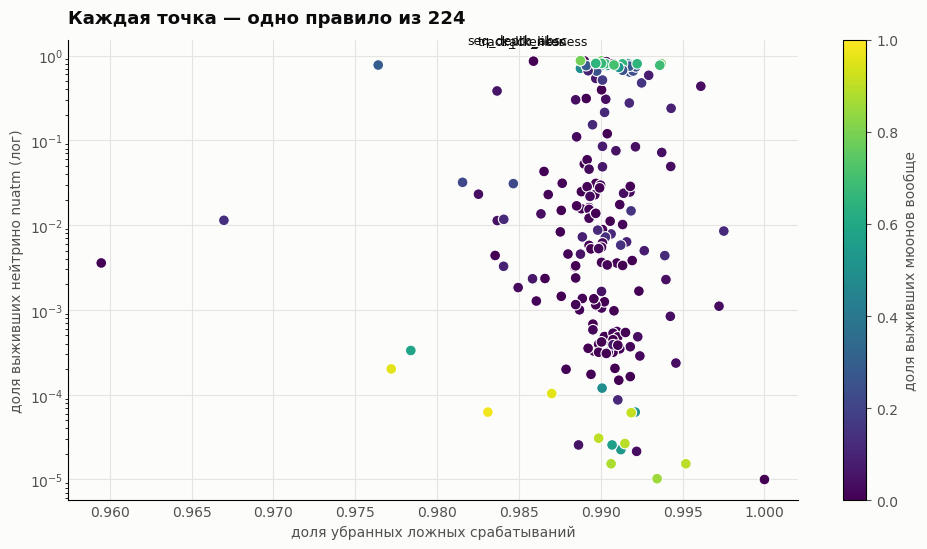

Тёмные точки вверху справа — вырожденные каты: убирают всё, включая мюонов.
Светлые вверху справа — искомое: фон убран, мюоны и нейтрино сохранены.


In [4]:
fig, ax = plt.subplots(figsize=(10, 5.6))
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.grid(color="#e5e4e0", lw=0.8); ax.set_axisbelow(True)
ax.tick_params(colors=MUTED, length=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
usable = frontier[frontier.fp <= 0.05]
scatter = ax.scatter(1 - usable.fp, np.maximum(usable.nuatm, 1e-5),
                     c=usable.mu_all, s=60, cmap="viridis", vmin=0, vmax=1,
                     edgecolor="white", lw=0.8, zorder=3)
for _, row in good.head(3).iterrows():
    ax.annotate(row.desc.split(" ")[0], (1 - row.fp, row.nuatm),
                textcoords="offset points", xytext=(-10, 12), fontsize=9,
                color=INK, ha="right")
ax.set_yscale("log")
ax.set_xlabel("доля убранных ложных срабатываний", color=MUTED)
ax.set_ylabel("доля выживших нейтрино nuatm (лог)", color=MUTED)
bar = fig.colorbar(scatter, ax=ax)
bar.set_label("доля выживших мюонов вообще", color=MUTED)
bar.ax.tick_params(colors=MUTED)
ax.set_title("Каждая точка — одно правило из 224", loc="left",
             fontsize=13, fontweight="bold", color=INK, pad=12)
plt.tight_layout()
plt.savefig(HERE / "figures" / "50_fp_cuts.png", dpi=150, bbox_inches="tight",
            facecolor=SURFACE)
plt.show()
print("Тёмные точки вверху справа — вырожденные каты: убирают всё, включая мюонов.")
print("Светлые вверху справа — искомое: фон убран, мюоны и нейтрино сохранены.")

## Шаг 3. Что означают выигравшие признаки

`track_likeness` — коэффициент детерминации линейной подгонки времени по глубине;
`extent_m` — наибольшее расстояние между двумя хитами события; `t_span` и `t_std`
— временная протяжённость; `seq_depth_absc` — **беззнаковая** корреляция порядка
хитов с глубиной.

Все они меряют, **насколько событие является длинным, чистым, упорядоченным
треком**, и ни один не меряет его направление.

Отсюда физический вывод: ложные срабатывания — это **короткие, беспорядочные,
плохо структурированные события**. И настоящие мюоны, и настоящие нейтрино суть
длинные чистые треки, поэтому кат по размеру и качеству отделяет ложные
срабатывания от обоих, тогда как направленный кат не может — по направлению
обманчивые мюоны и нейтрино совпадают, обе популяции выглядят восходящими.

## Шаг 4. Что происходит с экспериментальными событиями

In [5]:
present.show(
    good.head(8),
    {"desc": "кат", "exp_acc": "принятых exp осталось",
     "exp_clean": "отвергнутых exp осталось",
     "fp": "ложных срабатываний осталось", "mu_all": "мюонов осталось",
     "exp_over_mc": "во сколько раз exp переживает лучше",
     "exp_left": "принятых exp, штук"},
    rows="один кат",
    source=present.artefact_note(DATA / "51_cut_results.parquet"),
    note="Предпоследний столбец — отношение выживаемости принятых exp событий к "
         "выживаемости ложных срабатываний МК, каждое нормировано на свой "
         "низкоскоровый контроль. Единица означала бы одну и ту же популяцию.",
    decimals=4)
print(f"разброс этого отношения по всем годным катам: "
      f"{good.exp_over_mc.min():.2f} – {good.exp_over_mc.max():.2f}")

Строка — один кат.
Предпоследний столбец — отношение выживаемости принятых exp событий к выживаемости ложных
срабатываний МК, каждое нормировано на свой низкоскоровый контроль. Единица означала бы одну и
ту же популяцию.
Источник: стадия 51_fp_cuts, файл 51_cut_results.parquet, 2235 строк


кат,принятых exp осталось,отвергнутых exp осталось,ложных срабатываний осталось,мюонов осталось,во сколько раз exp переживает лучше,"принятых exp, штук"
track_likeness >= 0.6896,0.020100,0.762000,0.011200,0.785600,1.843100,219.000000
track_likeness < -inf or track_likeness > 0.7073,0.017700,0.741700,0.009900,0.769800,1.845000,192.600000
seq_depth_absc >= 0.8495,0.009000,0.682900,0.011200,0.740700,0.872200,98.000000
seq_depth_absc < -inf or seq_depth_absc > 0.8564,0.008300,0.666700,0.009700,0.728300,0.939800,90.800000
extent_m >= 144.7,0.017400,0.744900,0.010300,0.801500,1.820300,190.000000
t_std >= 172.4,0.019800,0.607500,0.010300,0.650400,2.059300,216.000000
t_span_core >= 468.4,0.022500,0.635100,0.010000,0.670900,2.385700,245.000000
t_std < -inf or t_std > 177.6,0.018900,0.596300,0.009300,0.640400,2.182100,206.400000


разброс этого отношения по всем годным катам: 0.87 – 3.41


Отношение гуляет от 0.87 до 3.09 в зависимости от того, каким катом
пользоваться: ниже единицы у `seq_depth_absc`, около 1.8 у `track_likeness` и
`extent_m`, около 2.9 у `t_span`. **Разброс слишком велик, чтобы утверждать
наличие остатка.** После ката остаётся от 90 до 290 экспериментальных событий, и
превышают ли они мюонное ожидание — этим методом не решается.

## Вывод

**Ответ положительный.** Двадцать два правила убирают 99% ложных срабатываний,
сохраняя не меньше 60% мюонной статистики. Лучшие:

* `track_likeness ≥ 0.690` — сохраняет **87% атмосферных нейтрино** и 46%
  астрофизических;
* `extent_m ≥ 144.7` — 81% и 50%;
* `seq_depth_absc ≥ 0.850` — 86% и 42%.

**Эффективность на нейтрино падает с 99.85% примерно до 87%** — потеря около
восьмой части, а не в десять тысяч раз, как я заключил из первого, слишком узкого
перебора.

**Выживаемость подтверждена вне выборки:** нейтрино разделены по МК-частям, и две
половины согласуются с точностью 0.0017 по всем правилам таблицы.

**Ограничение на мюонную статистику существенно.** Без него поиск возвращает
вырожденные каты, которые убирают ложные срабатывания вместе со всеми мюонами,
просто отбирая восходящие события.

**Остаток по эксперименту не определён:** отношение выживаемости гуляет от 0.87 до
3.09 по разным катам.